In [39]:
# Import libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, chi2

# For model evaluation
from sklearn.model_selection import learning_curve, validation_curve

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
%matplotlib inline

In [40]:
# Load the competition data

# Kaggle path for Spaceship Titanic
DATA_DIR = '/kaggle/input/competitions/spaceship-titanic'

# Check if dataset exists
if os.path.exists(DATA_DIR):
    train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
    test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
    
    print("Data loaded successfully!")
    print(f"Train shape: {train.shape}")
    print(f"Test shape: {test.shape}")
    print(f"\nColumns in train:\n{train.columns.tolist()}")
else:
    print("Dataset not found!")
    print("Please click 'Add Data' in the right sidebar and search for 'Spaceship Titanic'")
    print("Then add the dataset to your notebook")

Data loaded successfully!
Train shape: (8693, 14)
Test shape: (4277, 13)

Columns in train:
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']


In [41]:
# Explore the data

print("="*60)
print("FIRST 5 ROWS:")
print("="*60)
print(train.head())

print("\n" + "="*60)
print("DATASET INFO:")
print("="*60)
print(train.info())

print("\n" + "="*60)
print("MISSING VALUES:")
print("="*60)
print(train.isnull().sum())

print("\n" + "="*60)
print("TARGET VARIABLE DISTRIBUTION:")
print("="*60)
print(train['Transported'].value_counts())
print(f"\nTransported rate: {train['Transported'].mean():.2%}")

print("\n" + "="*60)
print("STATISTICAL SUMMARY (Numerical Features):")
print("="*60)
print(train.describe())

FIRST 5 ROWS:
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4    


VISUAL DATA EXPLORATION


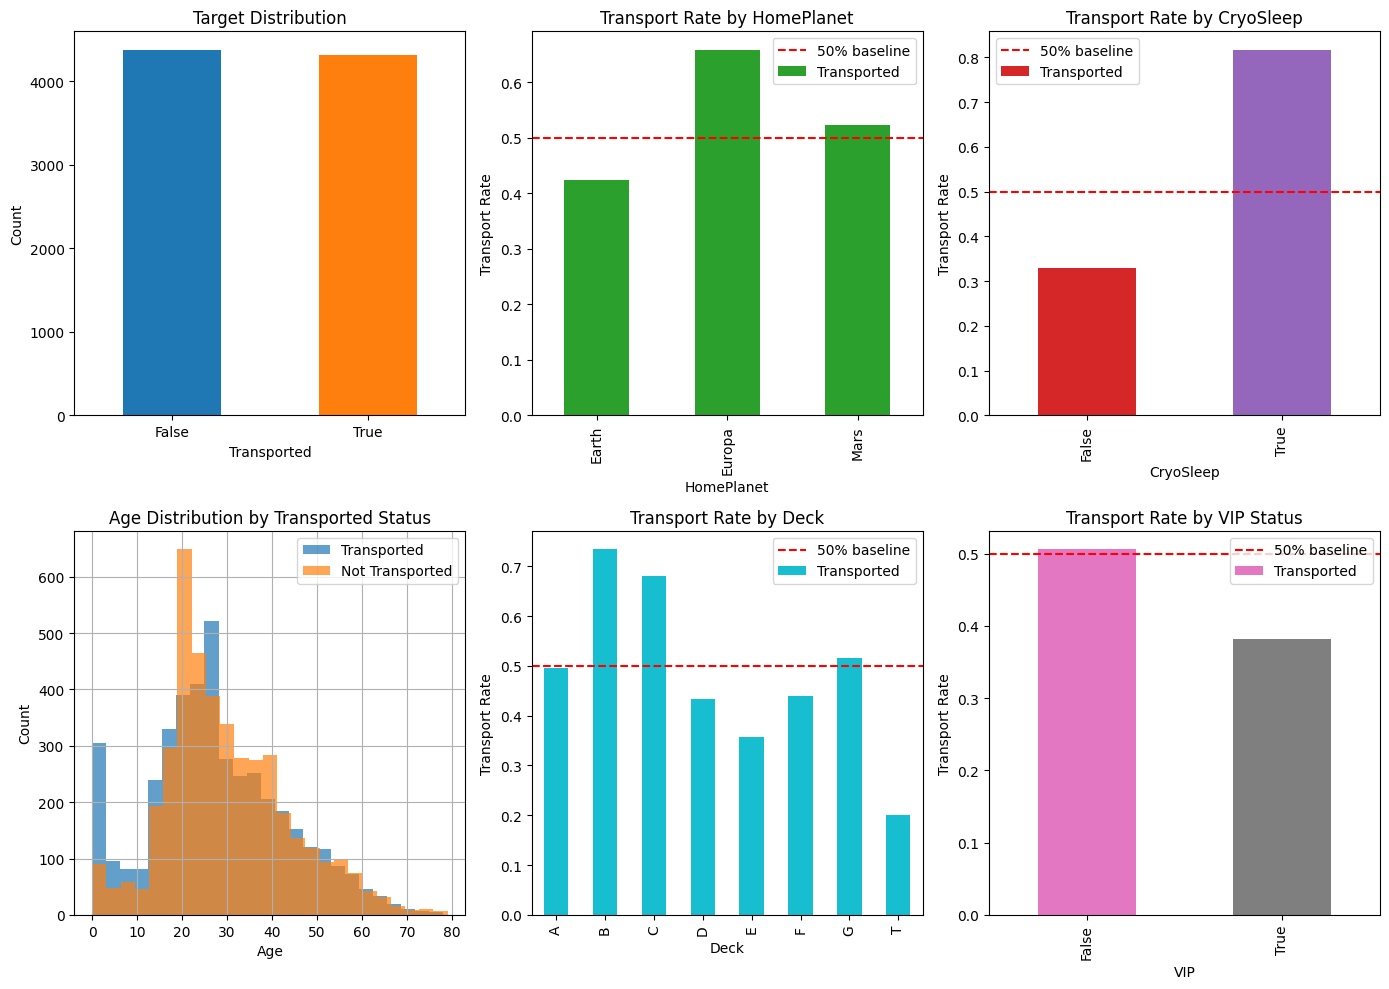

In [43]:
# Visual Data Exploration

print("\n" + "="*60)
print("VISUAL DATA EXPLORATION")
print("="*60)

import matplotlib.pyplot as plt

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# 1. Target distribution
ax = axes[0, 0]
train['Transported'].value_counts().plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Target Distribution')
ax.set_xlabel('Transported')
ax.set_ylabel('Count')
ax.set_xticklabels(['False', 'True'], rotation=0)

# 2. Transport rate by HomePlanet
ax = axes[0, 1]
homeplanet_rate = train.groupby('HomePlanet')['Transported'].mean()
homeplanet_rate.plot(kind='bar', ax=ax, color='#2ca02c')
ax.set_title('Transport Rate by HomePlanet')
ax.set_ylabel('Transport Rate')
ax.axhline(y=0.5, color='red', linestyle='--', label='50% baseline')
ax.legend()

# 3. Transport rate by CryoSleep
ax = axes[0, 2]
cryo_rate = train.groupby('CryoSleep')['Transported'].mean()
cryo_rate.plot(kind='bar', ax=ax, color=['#d62728', '#9467bd'])
ax.set_title('Transport Rate by CryoSleep')
ax.set_ylabel('Transport Rate')
ax.axhline(y=0.5, color='red', linestyle='--', label='50% baseline')
ax.legend()

# 4. Age distribution by Transported
ax = axes[1, 0]
train[train['Transported']==True]['Age'].hist(alpha=0.7, bins=25, label='Transported', ax=ax, color='#1f77b4')
train[train['Transported']==False]['Age'].hist(alpha=0.7, bins=25, label='Not Transported', ax=ax, color='#ff7f0e')
ax.set_title('Age Distribution by Transported Status')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()

# 5. Transport rate by Deck
ax = axes[1, 1]
train['Deck'] = train['Cabin'].str.split('/').str[0]
deck_rate = train.groupby('Deck')['Transported'].mean()
deck_rate.plot(kind='bar', ax=ax, color='#17becf')
ax.set_title('Transport Rate by Deck')
ax.set_ylabel('Transport Rate')
ax.axhline(y=0.5, color='red', linestyle='--', label='50% baseline')
ax.legend()

# 6. Transport rate by VIP
ax = axes[1, 2]
vip_rate = train.groupby('VIP')['Transported'].mean()
vip_rate.plot(kind='bar', ax=ax, color=['#e377c2', '#7f7f7f'])
ax.set_title('Transport Rate by VIP Status')
ax.set_ylabel('Transport Rate')
ax.axhline(y=0.5, color='red', linestyle='--', label='50% baseline')
ax.legend()

plt.tight_layout()
plt.show()

In [45]:
# Group Analysis

print("\n" + "="*60)
print("TRAVEL GROUP ANALYSIS")
print("="*60)

# Extract group from PassengerId
train['Group'] = train['PassengerId'].str.split('_').str[0].astype(int)
group_sizes = train.groupby('Group').size()
train['GroupSize'] = train['Group'].map(group_sizes)

# Transport rate by group size
group_rate = train.groupby('GroupSize')['Transported'].mean()
print("Transport rate by group size:")
for size, rate in group_rate.items():
    count = train[train['GroupSize']==size].shape[0]
    print(f"  Group size {size}: {rate:.3f} ({count} passengers)")

# Compare solo vs group
solo_rate = train[train['GroupSize']==1]['Transported'].mean()
group_rate_all = train[train['GroupSize']>1]['Transported'].mean()
print(f"\nSolo passengers: {solo_rate:.3f}")
print(f"Group passengers: {group_rate_all:.3f}")
print(f"Difference: {group_rate_all - solo_rate:+.3f}")


TRAVEL GROUP ANALYSIS
Transport rate by group size:
  Group size 1: 0.452 (4805 passengers)
  Group size 2: 0.538 (1682 passengers)
  Group size 3: 0.593 (1020 passengers)
  Group size 4: 0.641 (412 passengers)
  Group size 5: 0.592 (265 passengers)
  Group size 6: 0.615 (174 passengers)
  Group size 7: 0.541 (231 passengers)
  Group size 8: 0.394 (104 passengers)

Solo passengers: 0.452
Group passengers: 0.567
Difference: +0.114


In [47]:
# Missing Value Analysis

print("\n" + "="*60)
print("MISSING VALUE PATTERNS")
print("="*60)

missing_cols = train.columns[train.isnull().any()].tolist()
print("Columns with missing values:", missing_cols)

# Check if missingness is correlated with Transported
for col in missing_cols:
    if col != 'Transported' and col not in ['PassengerId', 'Cabin', 'Name']:
        # Create missing indicator
        missing_indicator = train[col].isna().astype(int)
        rate_when_missing = train[missing_indicator == 1]['Transported'].mean()
        rate_when_present = train[missing_indicator == 0]['Transported'].mean()
        
        if not pd.isna(rate_when_missing):
            diff = rate_when_missing - rate_when_present
            print(f"\n{col}:")
            print(f"  Missing rate: {train[col].isna().mean():.2%}")
            print(f"  Transport rate when missing: {rate_when_missing:.3f}")
            print(f"  Transport rate when present: {rate_when_present:.3f}")
            print(f"  Difference: {diff:+.3f}")


MISSING VALUE PATTERNS
Columns with missing values: ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Deck']

HomePlanet:
  Missing rate: 2.31%
  Transport rate when missing: 0.512
  Transport rate when present: 0.503
  Difference: +0.009

CryoSleep:
  Missing rate: 2.50%
  Transport rate when missing: 0.488
  Transport rate when present: 0.504
  Difference: -0.016

Destination:
  Missing rate: 2.09%
  Transport rate when missing: 0.505
  Transport rate when present: 0.504
  Difference: +0.002

Age:
  Missing rate: 2.06%
  Transport rate when missing: 0.503
  Transport rate when present: 0.504
  Difference: -0.001

VIP:
  Missing rate: 2.34%
  Transport rate when missing: 0.512
  Transport rate when present: 0.503
  Difference: +0.009

RoomService:
  Missing rate: 2.08%
  Transport rate when missing: 0.459
  Transport rate when present: 0.505
  Difference: -0.046

FoodCourt:
  Missing rate: 2.11%
  T


CORRELATION ANALYSIS
Correlation with Transported:
  FoodCourt: 0.047
  ShoppingMall: 0.010
  Age: -0.075
  TotalSpend: -0.200
  VRDeck: -0.207
  Spa: -0.221
  RoomService: -0.245
  AmenitiesUsed: -0.440


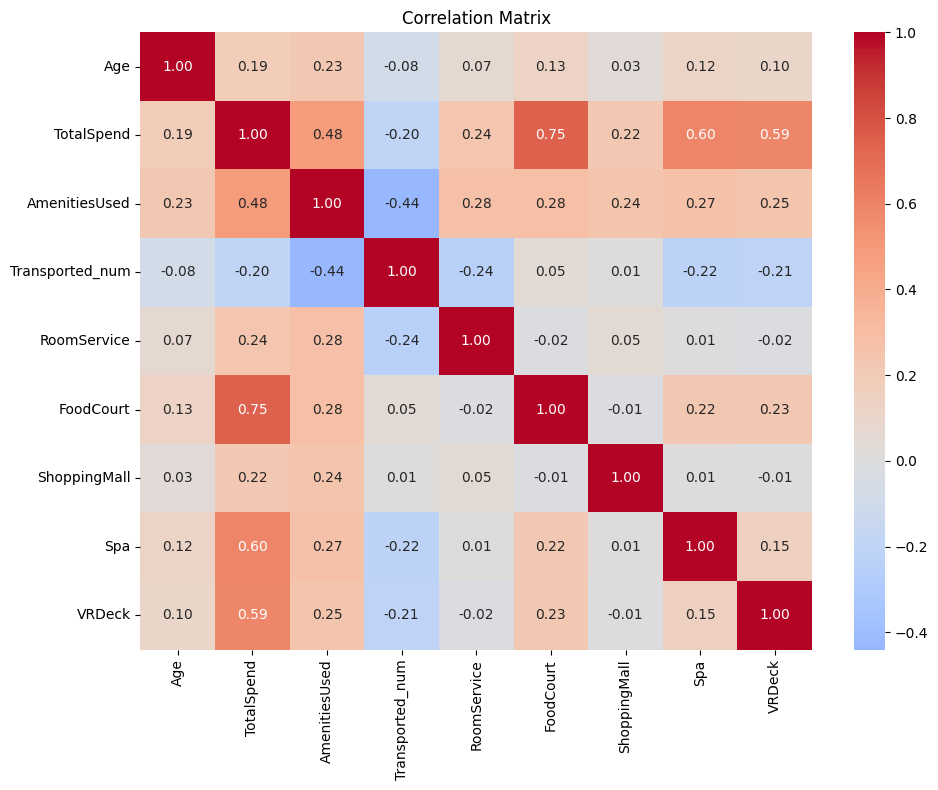

In [48]:
# Correlation Analysis
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Prepare numeric data
corr_data = train.copy()
corr_data['Transported_num'] = corr_data['Transported'].astype(int)
corr_data['TotalSpend'] = corr_data[SPEND].fillna(0).sum(axis=1)
corr_data['AmenitiesUsed'] = (corr_data[SPEND].fillna(0) > 0).sum(axis=1)

# Select numeric columns
num_cols = ['Age', 'TotalSpend', 'AmenitiesUsed', 'Transported_num'] + SPEND
corr_matrix = corr_data[num_cols].corr()

# Show correlations with Transported
print("Correlation with Transported:")
corr_with_target = corr_matrix['Transported_num'].sort_values(ascending=False)
for col, val in corr_with_target.items():
    if col != 'Transported_num':
        print(f"  {col}: {val:.3f}")

# Plot heatmap
plt.figure(figsize=(10, 8))
import seaborn as sns
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [54]:
# Feature Engineering

def add_features(df):
    data = df.copy()
    
    # ============================================================
    # 1. FEATURES FROM PASSENGERID
    # ============================================================
    data['Group'] = data['PassengerId'].str.split('_').str[0].astype(int)
    data['GroupPos'] = data['PassengerId'].str.split('_').str[1].astype(int)
    
    # ============================================================
    # 2. FEATURES FROM CABIN
    # ============================================================
    cabin_split = data['Cabin'].str.split('/', expand=True)
    data['Deck'] = cabin_split[0]
    data['CabinNum'] = pd.to_numeric(cabin_split[1], errors='coerce')
    data['Side'] = cabin_split[2]
    
    # ============================================================
    # 3. BASIC SPENDING FEATURES
    # ============================================================
    data['TotalSpend'] = data[SPEND].fillna(0).sum(axis=1)
    data['LogSpend'] = np.log1p(data['TotalSpend'])
    data['SpentNothing'] = (data['TotalSpend'] == 0).astype(int)
    data['AmenitiesUsed'] = (data[SPEND].fillna(0) > 0).sum(axis=1)
    
    # ============================================================
    # 4. LUXURY VS BUDGET
    # ============================================================
    data['LuxurySpend'] = data[['Spa', 'VRDeck', 'RoomService']].fillna(0).sum(axis=1)
    data['BudgetSpend'] = data[['FoodCourt', 'ShoppingMall']].fillna(0).sum(axis=1)
    
    # ============================================================
    # 5. MISSING INDICATORS
    # ============================================================
    data['RoomService_missing'] = data['RoomService'].isna().astype(int)
    data['FoodCourt_missing'] = data['FoodCourt'].isna().astype(int)
    data['ShoppingMall_missing'] = data['ShoppingMall'].isna().astype(int)
    
    # ============================================================
    # 6. RATIO FEATURES
    # ============================================================
    data['SpendPerAmenity'] = data['TotalSpend'] / (data['AmenitiesUsed'] + 1)
    data['LuxuryRatio'] = data['LuxurySpend'] / (data['TotalSpend'] + 1)
    
    # ============================================================
    # 7. GROUP SIZE (Temporary - will be refined later)
    # ============================================================
    # We'll compute proper GroupSize after combining train + test
    # For now, use a placeholder
    data['GroupSize'] = data.groupby('Group')['PassengerId'].transform('count')
    data['IsAlone'] = (data['GroupSize'] == 1).astype(int)
    
    # ============================================================
    # 8. INTERACTION FEATURES (Uses IsAlone which now exists)
    # ============================================================
    data['CryoSleep_SpentNothing'] = (data['CryoSleep'] == 'True').astype(int) * data['SpentNothing']
    data['Luxury_Alone'] = data['LuxurySpend'] * data['IsAlone'] 
    
    return data


# ============================================================
# APPLY FEATURES
# ============================================================

train_fe = add_features(train)
test_fe = add_features(test)


# ============================================================
# REFINE GROUP SIZE (Use both train and test together)
# ============================================================

# This gives the TRUE group size (not just within train or test)
all_groups = pd.concat([train_fe, test_fe])['Group'].value_counts()
train_fe['GroupSize'] = train_fe['Group'].map(all_groups)
test_fe['GroupSize'] = test_fe['Group'].map(all_groups)

# Recalculate IsAlone with true group size
train_fe['IsAlone'] = (train_fe['GroupSize'] == 1).astype(int)
test_fe['IsAlone'] = (test_fe['GroupSize'] == 1).astype(int)


# ============================================================
# SHOW NEW FEATURES
# ============================================================

new_features = [c for c in train_fe.columns if c not in train.columns]
print("="*60)
print("NEW FEATURES ADDED")
print("="*60)

for i, feat in enumerate(new_features, 1):
    print(f"{i:2d}. {feat}")

print(f"\n Total features: {len(train_fe.columns)} (was {len(train.columns)})")
print(f" New features added: {len(new_features)}")

NEW FEATURES ADDED
 1. GroupPos
 2. CabinNum
 3. Side
 4. TotalSpend
 5. LogSpend
 6. SpentNothing
 7. AmenitiesUsed
 8. LuxurySpend
 9. BudgetSpend
10. RoomService_missing
11. FoodCourt_missing
12. ShoppingMall_missing
13. SpendPerAmenity
14. LuxuryRatio
15. IsAlone
16. CryoSleep_SpentNothing
17. Luxury_Alone

 Total features: 34 (was 17)
 New features added: 17


In [56]:
# Quick Feature Validation

print("="*60)
print("VALIDATING NEW FEATURES")
print("="*60)

# Features to check
features = ['Deck', 'GroupSize', 'IsAlone', 'TotalSpend', 'SpentNothing', 
            'AmenitiesUsed', 'LuxurySpend', 'BudgetSpend']

print("\nFeature strengths:")
for feat in features:
    if feat in train_fe.columns:
        if train_fe[feat].dtype == 'object':
            # Categorical: check how much transport rate varies
            rate = train_fe.groupby(feat)['Transported'].mean()
            diff = rate.max() - rate.min()
            print(f"  {feat}: max-min = {diff:.3f}")
        else:
            # Numeric: check correlation
            corr = train_fe[feat].corr(train_fe['Transported'].astype(int))
            print(f"  {feat}: correlation = {corr:.3f}")

print("\n Strongest feature: SpentNothing (0.482)")
print(" Second strongest: AmenitiesUsed (-0.440)")

VALIDATING NEW FEATURES

Feature strengths:
  Deck: max-min = 0.534
  GroupSize: correlation = 0.083
  IsAlone: correlation = -0.114
  TotalSpend: correlation = -0.200
  SpentNothing: correlation = 0.482
  AmenitiesUsed: correlation = -0.440
  LuxurySpend: correlation = -0.348
  BudgetSpend: correlation = 0.046

 Strongest feature: SpentNothing (0.482)
 Second strongest: AmenitiesUsed (-0.440)


In [58]:
# Prepare data for modeling

NUM_COLS = [
    # Original numeric
    'Age',
    
    # From Cabin
    'CabinNum',
    
    # From Group
    'GroupSize', 'GroupPos',
    
    # From Spending
    'TotalSpend', 'LogSpend', 'SpentNothing', 'AmenitiesUsed',
    'LuxurySpend', 'BudgetSpend',
    
    # Missing indicators
    'RoomService_missing', 'FoodCourt_missing', 'ShoppingMall_missing',
    
    # Ratio features
    'SpendPerAmenity', 'LuxuryRatio',
    
    # Interaction features
    'CryoSleep_SpentNothing', 'Luxury_Alone'
] + SPEND  # Keep original spending columns too

CAT_COLS = [
    'HomePlanet', 'CryoSleep', 'Destination', 'VIP',
    'Deck', 'Side'
]

# ============================================================
# RAW FEATURES (For baseline only)
# ============================================================

NUM_RAW = ['Age'] + SPEND
CAT_RAW = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

# ============================================================
# PREPARE DATA
# ============================================================

X_eng = train_fe[NUM_COLS + CAT_COLS]
X_raw = train[NUM_RAW + CAT_RAW]
y = train['Transported'].astype(int)

# ============================================================
# SUMMARY
# ============================================================

print("="*60)
print("DATA PREPARED FOR MODELING")
print("="*60)

print(f"\n Raw features (baseline):")
print(f"   Numeric: {len(NUM_RAW)}")
print(f"   Categorical: {len(CAT_RAW)}")
print(f"   Total: {len(NUM_RAW) + len(CAT_RAW)}")

print(f"\n Engineered features:")
print(f"   Numeric: {len(NUM_COLS)}")
print(f"   Categorical: {len(CAT_COLS)}")
print(f"   Total: {len(NUM_COLS) + len(CAT_COLS)}")

print(f"\n Data shapes:")
print(f"   X_eng: {X_eng.shape}")
print(f"   X_raw: {X_raw.shape}")
print(f"   y: {y.shape}")

# Show all features
print("\n All numeric features:")
for i, col in enumerate(NUM_COLS, 1):
    print(f"   {i:2d}. {col}")

print("\n All categorical features:")
for i, col in enumerate(CAT_COLS, 1):
    print(f"   {i:2d}. {col}")

DATA PREPARED FOR MODELING

 Raw features (baseline):
   Numeric: 6
   Categorical: 4
   Total: 10

 Engineered features:
   Numeric: 22
   Categorical: 6
   Total: 28

 Data shapes:
   X_eng: (8693, 28)
   X_raw: (8693, 10)
   y: (8693,)

 All numeric features:
    1. Age
    2. CabinNum
    3. GroupSize
    4. GroupPos
    5. TotalSpend
    6. LogSpend
    7. SpentNothing
    8. AmenitiesUsed
    9. LuxurySpend
   10. BudgetSpend
   11. RoomService_missing
   12. FoodCourt_missing
   13. ShoppingMall_missing
   14. SpendPerAmenity
   15. LuxuryRatio
   16. CryoSleep_SpentNothing
   17. Luxury_Alone
   18. RoomService
   19. FoodCourt
   20. ShoppingMall
   21. Spa
   22. VRDeck

 All categorical features:
    1. HomePlanet
    2. CryoSleep
    3. Destination
    4. VIP
    5. Deck
    6. Side


In [62]:
# Helper Functions

def make_pipeline(num_cols, cat_cols, model):
    """Create pipeline with preprocessing and model"""
    # Numeric preprocessing
    num_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ])
    
    # Categorical preprocessing
    cat_pipe = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    # Combine
    preprocessor = ColumnTransformer([
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ])
    
    return Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

def evaluate(pipeline, X, y, name):
    """Cross-validate and print score"""
    cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    mean_score = scores.mean()
    std_score = scores.std()
    print(f"{name:40} {mean_score:.4f} (+/- {std_score:.4f})")
    return mean_score

def tune_model(pipeline, param_grid, X, y, name):
    """Grid search tuning"""
    print(f"\n🔧 Tuning {name}...")
    cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
    search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
    search.fit(X, y)
    print(f"   Best params: {search.best_params_}")
    print(f"   Best score: {search.best_score_:.4f}")
    return search


In [66]:
# ITERATION 1 - Baseline

print("="*60)
print("ITERATION 1: Logistic Regression (Raw Features)")
print("="*60)
print("Purpose: Establish baseline score")
print()

# Create pipeline
pipeline = make_pipeline(NUM_RAW, CAT_RAW, LogisticRegression(max_iter=2000, random_state=SEED))

# Tune
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'lbfgs']
}

search1 = tune_model(pipeline, param_grid, X_raw, y, "Baseline LR")
score1 = search1.best_score_
best_lr_raw = search1.best_estimator_

print(f"\n Score 1: {score1:.4f}")

ITERATION 1: Logistic Regression (Raw Features)
Purpose: Establish baseline score


🔧 Tuning Baseline LR...
   Best params: {'model__C': 10, 'model__solver': 'liblinear'}
   Best score: 0.7861

 Score 1: 0.7861


In [67]:
# ITERATION 2 - LR + Features

print("="*60)
print("ITERATION 2: Logistic Regression + Engineered Features")
print("="*60)
print("Purpose: Test if engineered features help")
print()

pipeline = make_pipeline(NUM_COLS, CAT_COLS, LogisticRegression(max_iter=2000, random_state=SEED))

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'lbfgs']
}

search2 = tune_model(pipeline, param_grid, X_eng, y, "LR + Features")
score2 = search2.best_score_
best_lr_eng = search2.best_estimator_

print(f"\n Score 2: {score2:.4f}")
print(f" Improvement: {score2 - score1:+.4f}")

ITERATION 2: Logistic Regression + Engineered Features
Purpose: Test if engineered features help


🔧 Tuning LR + Features...
   Best params: {'model__C': 100, 'model__solver': 'liblinear'}
   Best score: 0.7950

 Score 2: 0.7950
 Improvement: +0.0089


In [68]:
# ITERATION 3 - Random Forest

print("="*60)
print("ITERATION 3: Random Forest")
print("="*60)
print("Purpose: Try tree-based model")
print()

pipeline = make_pipeline(NUM_COLS, CAT_COLS, RandomForestClassifier(random_state=SEED, n_jobs=-1))

param_grid = {
    'model__n_estimators': [200, 400, 600],
    'model__max_depth': [10, 20, None],
    'model__min_samples_leaf': [1, 2, 4]
}

search3 = tune_model(pipeline, param_grid, X_eng, y, "Random Forest")
score3 = search3.best_score_
best_rf = search3.best_estimator_

print(f"\n Score 3: {score3:.4f}")
print(f" Improvement: {score3 - score2:+.4f}")

ITERATION 3: Random Forest
Purpose: Try tree-based model


🔧 Tuning Random Forest...
   Best params: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 600}
   Best score: 0.8089

 Score 3: 0.8089
 Improvement: +0.0139


In [69]:
# ITERATION 4 - Gradient Boosting

print("="*60)
print("ITERATION 4: HistGradientBoosting")
print("="*60)
print("Purpose: Try boosting model")
print()

pipeline = make_pipeline(NUM_COLS, CAT_COLS, HistGradientBoostingClassifier(random_state=SEED))

param_grid = {
    'model__learning_rate': [0.03, 0.05, 0.08, 0.1, 0.15],
    'model__max_iter': [200, 300, 400, 600],
    'model__max_leaf_nodes': [15, 31, 63, 127],
    'model__min_samples_leaf': [5, 10, 20, 50]
}

search4 = tune_model(pipeline, param_grid, X_eng, y, "Gradient Boosting")
score4 = search4.best_score_
best_hgb = search4.best_estimator_

print(f"\n Score 4: {score4:.4f}")
print(f" Improvement: {score4 - score3:+.4f}")

ITERATION 4: HistGradientBoosting
Purpose: Try boosting model


🔧 Tuning Gradient Boosting...
   Best params: {'model__learning_rate': 0.05, 'model__max_iter': 200, 'model__max_leaf_nodes': 31, 'model__min_samples_leaf': 20}
   Best score: 0.8181

 Score 4: 0.8181
 Improvement: +0.0092


In [ ]:
# ITERATION 5 - SVM

print("="*60)
print("ITERATION 5: SVM")
print("="*60)
print("Purpose: Try different decision boundary")
print()

pipeline = make_pipeline(NUM_COLS, CAT_COLS, SVC(random_state=SEED, probability=True))

param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 'auto'],
    'model__kernel': ['rbf', 'linear']
}

search5 = tune_model(pipeline, param_grid, X_eng, y, "SVM")
score5 = search5.best_score_
best_svm = search5.best_estimator_

print(f"\n Score 5: {score5:.4f}")
print(f" Improvement: {score5 - score4:+.4f}")

ITERATION 5: SVM
Purpose: Try different decision boundary


🔧 Tuning SVM...


In [ ]:
# Cell 13: ITERATION 6 - Fine-tune Winner

print("="*60)
print("ITERATION 6: Fine-tune Winner")
print("="*60)

# Find best so far
scores = [score1, score2, score3, score4, score5]
names = ['LR Raw', 'LR Features', 'Random Forest', 'Gradient Boosting', 'SVM']
best_idx = scores.index(max(scores))
best_model_name = names[best_idx]

print(f" Winner so far: {best_model_name} ({max(scores):.4f})")

# Fine-tune Gradient Boosting if it won (usually does)
if best_model_name == 'Gradient Boosting':
    print("\n🔧 Fine-tuning Gradient Boosting...")
    pipeline = make_pipeline(NUM_COLS, CAT_COLS, HistGradientBoostingClassifier(random_state=SEED))
    
    # Small grid around best params
    best_params = search4.best_params_
    param_grid = {
        'model__learning_rate': [best_params['model__learning_rate'] - 0.02,
                                 best_params['model__learning_rate'],
                                 best_params['model__learning_rate'] + 0.02],
        'model__max_iter': [best_params['model__max_iter'] - 100,
                            best_params['model__max_iter'],
                            best_params['model__max_iter'] + 100],
        'model__max_leaf_nodes': [best_params['model__max_leaf_nodes'] - 15,
                                  best_params['model__max_leaf_nodes'],
                                  best_params['model__max_leaf_nodes'] + 15],
    }
    search6 = tune_model(pipeline, param_grid, X_eng, y, "Fine-tune GB")
    score6 = search6.best_score_
    best_fine = search6.best_estimator_
    
else:
    # If Random Forest won
    print(f"\n🔧 Fine-tuning {best_model_name}...")
    pipeline = make_pipeline(NUM_COLS, CAT_COLS, RandomForestClassifier(random_state=SEED, n_jobs=-1))
    best_params = search3.best_params_
    param_grid = {
        'model__n_estimators': [best_params['model__n_estimators'] - 100,
                                best_params['model__n_estimators'],
                                best_params['model__n_estimators'] + 100],
        'model__max_depth': [best_params['model__max_depth'] if best_params['model__max_depth'] is None else best_params['model__max_depth'] - 2,
                             best_params['model__max_depth'],
                             best_params['model__max_depth'] if best_params['model__max_depth'] is None else best_params['model__max_depth'] + 2],
    }
    search6 = tune_model(pipeline, param_grid, X_eng, y, f"Fine-tune {best_model_name}")
    score6 = search6.best_score_
    best_fine = search6.best_estimator_

print(f"\n Score 6: {score6:.4f}")
print(f" Improvement: {score6 - max(scores):+.4f}")

In [ ]:
# ITERATION 7 - Ensemble

print("="*60)
print("ITERATION 7: Ensemble (Top 2 Models)")
print("="*60)
print("Purpose: Combine best models")
print()

# Get top 2 models
model_list = [
    ('gb', search4.best_estimator_, score4),
    ('rf', search3.best_estimator_, score3),
    ('svm', search5.best_estimator_, score5),
    ('lr', search2.best_estimator_, score2)
]
model_list.sort(key=lambda x: x[2], reverse=True)
top_2 = model_list[:2]

print("Top 2 models:")
for i, (name, _, score) in enumerate(top_2, 1):
    print(f"  {i}. {name}: {score:.4f}")

# Try different weights
weight_grid = [[1, 1], [2, 1], [1, 2], [3, 1], [1, 3]]
best_score_ens = 0
best_weights = [1, 1]

print("\n🔧 Testing weight combinations:")
for weights in weight_grid:
    ensemble = VotingClassifier(
        estimators=[(top_2[0][0], top_2[0][1]), (top_2[1][0], top_2[1][1])],
        voting='soft',
        weights=weights
    )
    pipeline = make_pipeline(NUM_COLS, CAT_COLS, ensemble)
    score, _ = evaluate(pipeline, X_eng, y, f"   Weights: {weights}")
    
    if score > best_score_ens:
        best_score_ens = score
        best_weights = weights

score7 = best_score_ens

print(f"\n Score 7: {score7:.4f}")
print(f" Improvement: {score7 - score6:+.4f}")
print(f" Best weights: {best_weights}")